# Assignment 1 Task 3

In [172]:
# Do not install the unrelated `commpy` package here; it breaks
# `from commpy.channelcoding import ...` in this environment.
%pip install -q scikit-commpy


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Imports

In [173]:

import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from scipy.signal import butter, freqz, filtfilt
from commpy.channelcoding import Trellis, conv_encode, viterbi_decode
from numpy.lib.stride_tricks import sliding_window_view


In [205]:
# matlab uses deprecated method to generate this
# thus it needs to be hardcoded to work in python
def get_P():
    return np.array([
        1, -1, -1, 1, -1, -1, -1, -1, 1, 1, 1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1, -1, 1, -1, 1, 1, 1, -1, -1, 1, -1, 1, -1, 1, -1, 1, 1, -1, 1, 1, -1, 1, 1, 1, -1, -1, 1, 1, 1, 1, 1, -1, 1, 1, 1, -1, 1, 1, -1, 1, 1, -1, 1, -1
    ])

In [174]:
# Load signal
data = scipy.io.loadmat('Signals_task3/Signal3.mat')
r = data['R'].flatten()

# System parameters
fs = 44100
fc = 10000
Nsc = 128
Ncp = 20
Tsym = 58 * 10**-3



### Demodulation

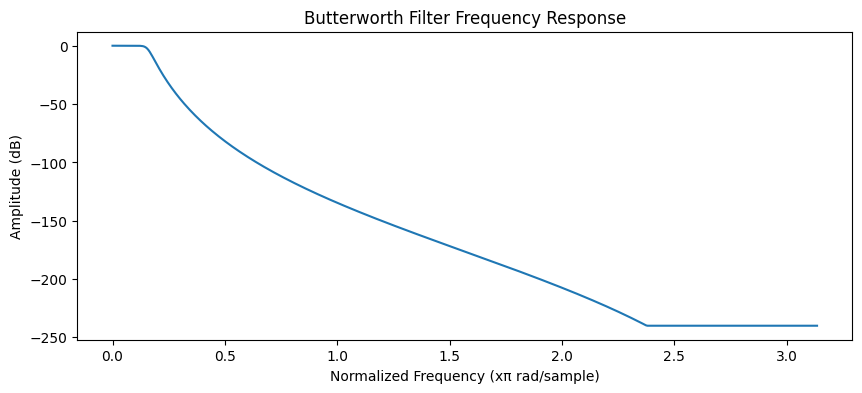

In [175]:

n = np.arange(len(r))
r_I =  2 * r * np.cos(2 * np.pi * fc * n / fs)
r_Q = -2 * r * np.sin(2 * np.pi * fc * n / fs)

b, a = butter(8, 0.05)
r_I_filt = filtfilt(b, a, r_I)
r_Q_filt = filtfilt(b, a, r_Q)

w, h = freqz(b, a)
plt.plot(w, 20 * np.log10(np.maximum(np.abs(h), 1e-12)))
plt.title("Butterworth Filter Frequency Response")
plt.xlabel("Normalized Frequency (xπ rad/sample)")
plt.ylabel("Amplitude (dB)")
plt.grid()
plt.show()


## AD conversion and down sampling

In [176]:

D = fs * Tsym / Nsc
sample_idx = np.arange(0, len(r_I_filt), D)

r_I_down = np.interp(sample_idx, np.arange(len(r_I_filt)), r_I_filt)
r_Q_down = np.interp(sample_idx, np.arange(len(r_Q_filt)), r_Q_filt)
r_bb = r_I_down + 1j * r_Q_down

print(f"D={D:.6f}, r_bb length={len(r_bb)}, ~{len(r_bb)//(Nsc+Ncp)} OFDM symbols")


D=19.982813, r_bb length=6359, ~42 OFDM symbols


## Synchronization and Removal of the Cyclic Prefix

Sync peak at OFDM data sample 4023


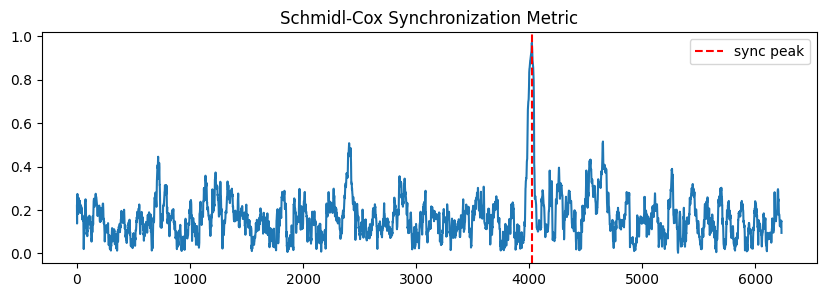

In [177]:

Tper = Nsc // 2

wins  = sliding_window_view(r_bb, 2 * Tper)
gamma = np.sum(wins[:, :Tper] * np.conj(wins[:, Tper:]), axis=1)
phi1  = np.sum(np.abs(wins[:, :Tper])**2, axis=1)
phi2  = np.sum(np.abs(wins[:, Tper:])**2, axis=1)
mu    = np.abs(gamma) / np.sqrt(phi1 * phi2 + 1e-10)

peak = int(np.argmax(mu))
print(f"Sync peak at OFDM data sample {peak}")

plt.figure(figsize=(10, 3))
plt.plot(mu)
plt.axvline(peak, color="r", ls="--", label="sync peak")
plt.title("Schmidl-Cox Synchronization Metric")
plt.grid()
plt.legend()
plt.show()


## FFT

In [ ]:
# CommPy interprets the second generator polynomial with the opposite bit order
# compared to the Matlab convention used in the project description.
trellis = Trellis(memory=np.array([5]), g_matrix=np.array([[0o77, 0o51]]))


def qpsk_map(bits):
    bits = np.asarray(bits, dtype=int)
    out = np.empty(len(bits) // 2, dtype=complex)
    out.real = 1 - 2 * bits[0::2]
    out.imag = 1 - 2 * bits[1::2]
    return out


def known_length_symbol(length):
    u_m = np.array(list(map(int, format(length, "010b"))) + [0] * 5, dtype=int)
    coded = conv_encode(u_m, trellis, termination="cont")
    return np.concatenate([qpsk_map(coded[:30]), np.full(Nsc - 15, 1 + 1j)])


def weighted_soft_bits(symbols, H):
    flat = symbols.ravel()
    weight = np.abs(H.ravel()) ** 2
    out = np.empty(flat.size * 2, dtype=float)
    out[0::2] = flat.real * weight
    out[1::2] = flat.imag * weight
    return out


def bits_to_ascii(bits, length):
    bits = np.asarray(bits, dtype=int)[: 7 * length]
    chars = []
    for start in range(0, len(bits) - 6, 7):
        chars.append(chr(int("".join(bits[start:start + 7].astype(str)), 2)))
    return "".join(chars)


def message_score(message):
    if not message:
        return -1e9
    printable = sum((32 <= ord(ch) <= 126) or ch in "\n\r\t" for ch in message) / len(message)
    spaces = message.count(" ") / len(message)
    letters = sum(ch.isalpha() for ch in message) / len(message)
    common = sum(
        message.lower().count(token)
        for token in (" any ", " linear ", " combination ", " gaussian ", " random ", " variables ", " variable ", " again ", " is ", " and ", " of ")
    )
    return printable + 0.5 * spaces + 0.3 * letters + 0.1 * common


def extract_fft_blocks(start_cp):
    n_sym = (len(r_bb) - start_cp) // (Nsc + Ncp)
    if n_sym < 8:
        return None
    blocks = r_bb[start_cp : start_cp + n_sym * (Nsc + Ncp)].reshape(n_sym, Nsc + Ncp)
    return np.fft.fft(blocks[:, Ncp:], axis=1)


length_cache = {length: known_length_symbol(length) for length in range(1, 109)}

best = None
search_range = range(max(Ncp, peak - 25), peak - 16)

for T0 in search_range:
    t0 = T0 - Ncp
    X_cand = extract_fft_blocks(t0)
    if X_cand is None:
        continue

    ranked = []
    for length, known_sym in length_cache.items():
        H_len = X_cand[1] / known_sym
        second_diff = H_len[2:] - 2 * H_len[1:-1] + H_len[:-2]
        cost = np.mean(np.abs(second_diff[:30]) ** 2) + 3.0 * np.abs(H_len[15] - H_len[14]) ** 2
        ranked.append((float(cost), length, known_sym))

    ranked.sort(key=lambda item: item[0])

    for length_cost, length, known_sym in ranked[:5]:
        n_payload = int(np.ceil((7 * length + 5) / Nsc))
        if X_cand.shape[0] < 2 + n_payload:
            continue

        H_len = X_cand[1] / known_sym
        payload = X_cand[2 : 2 + n_payload] / H_len
        H_payload = np.tile(H_len, (payload.shape[0], 1))

        for variant, work in (
            ("id", payload),
            ("conj", np.conj(payload)),
            ("j", 1j * payload),
            ("neg", -payload),
            ("-j", -1j * payload),
        ):
            needed = 2 * (7 * length + 5)
            soft = weighted_soft_bits(work, H_payload)[:needed]
            decoded = viterbi_decode(soft, trellis, tb_depth=20, decoding_type="unquantized").astype(int)
            message = bits_to_ascii(decoded, length)
            score = message_score(message)

            candidate = {
                "score": score,
                "T0": T0,
                "t0": t0,
                "length": length,
                "length_cost": length_cost,
                "variant": variant,
                "X": X_cand,
                "H": H_len,
                "payload_eq": work,
                "message": message,
            }

            if best is None or candidate["score"] > best["score"]:
                best = candidate


if best is None:
    raise RuntimeError("No valid task 3 receiver candidate found.")

X = best["X"]
H_full = best["H"]
X_eq = best["payload_eq"]
l_m = best["length"]
message = best["message"]

print(f"Best OFDM data start: {best['T0']}")
print(f"Best CP start: {best['t0']}")
print(f"Best decoded length: {l_m} characters")
print(f"Best variant: {best['variant']}")
print()
print(message)




Best OFDM data start: 4004
Best CP start: 3984
Best decoded length: 104 characters
Best variant: id

Any linear combination of G`I9an random wS4gvbhO is agaj	P9B(
B?)an rando=B _$31E.  LdM cUjt{]_r


## Channel Estimation, Pilot Removal and Calibration

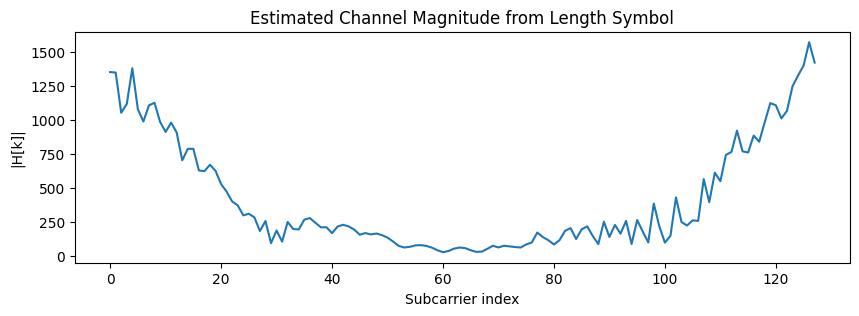

In [179]:

plt.figure(figsize=(10, 3))
plt.plot(np.abs(H_full))
plt.title("Estimated Channel Magnitude from Length Symbol")
plt.xlabel("Subcarrier index")
plt.ylabel("|H[k]|")
plt.grid()
plt.show()


## Pilot removal and equalization

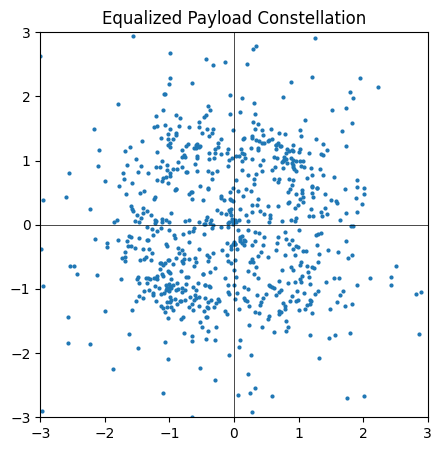

In [180]:

plt.figure(figsize=(5, 5))
plt.scatter(X_eq.real.flatten(), X_eq.imag.flatten(), s=4)
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.axhline(0, color="k", lw=0.5)
plt.axvline(0, color="k", lw=0.5)
plt.title("Equalized Payload Constellation")
plt.grid()
plt.show()


## QPSK

In [181]:

# Decoding is handled in the previous cell so that timing, channel estimation,
# and message-length search are evaluated together.


## Decoding and ASCII

In [182]:

print(f"Message length: {l_m} characters")
print(message)


Message length: 104 characters
Any linear combination of G`I9an random wS4gvbhO is agaj	P9B(
B?)an rando=B _$31E.  LdM cUjt{]_r
